# viz_one — per-image entropy-field stack across ViT depth

Forwards one image through `google/vit-base-patch16-224`, treats the
per-patch differential entropy at each transformer-block output as a
scalar field on the 14×14 patch grid, and renders the per-layer field
along with its gradient quiver, streamlines, Laplacian, and ΔH.

**Parametrisation.** The cell below sets `IMAGE_PATH`. Override via the
environment variable `ERIS_IMAGE` when running through nbconvert, or
edit the cell directly when running interactively.

In [1]:
import os
from pathlib import Path

# Default image — overridden by ERIS_IMAGE for batch runs.
DEFAULT_IMAGE = "synth_gabor.jpg"
IMAGE_PATH = os.environ.get("ERIS_IMAGE", DEFAULT_IMAGE)

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
REPO = NB_DIR if (NB_DIR / "pyproject.toml").exists() else NB_DIR.parent
IMG_PATH = (REPO / "images" / IMAGE_PATH).resolve() \
    if not Path(IMAGE_PATH).is_absolute() else Path(IMAGE_PATH)
IMG_NAME = IMG_PATH.stem
RESULTS_DIR = REPO / "results" / IMG_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"image: {IMG_PATH}")
print(f"name : {IMG_NAME}")
print(f"out  : {RESULTS_DIR}")

image: /home/varun/research/eris/images/symmetric.jpg
name : symmetric
out  : /home/varun/research/eris/results/symmetric


In [2]:
import matplotlib.animation as animation
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import scipy.stats
import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GRID = 14
HIDDEN = 768
N_BLOCKS = 12

## 1. Forward pass + per-patch entropy

In [3]:
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTModel.from_pretrained("google/vit-base-patch16-224").to(DEVICE).eval()

img_pil = Image.open(IMG_PATH).convert("RGB")
inputs = processor(images=img_pil, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out = model(**inputs, output_hidden_states=True)

# hidden_states: tuple of length n_blocks+1 = 13. index 0 = patch-embedding
# pre-block, 1..12 = post each transformer block.
assert len(out.hidden_states) == N_BLOCKS + 1, len(out.hidden_states)
print(f"hidden_states: {len(out.hidden_states)} entries; analysing 1..{N_BLOCKS}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


hidden_states: 13 entries; analysing 1..12


In [4]:
def entropy_field(hidden: torch.Tensor) -> np.ndarray:
    """hidden: (1, 197, 768) → (14, 14) per-patch differential entropy."""
    h = hidden.detach().cpu().float().numpy()
    assert h.shape == (1, 197, HIDDEN), h.shape
    h = h[0, 1:, :]                              # drop CLS → (196, 768)
    assert h.shape == (GRID * GRID, HIDDEN)
    h = h.reshape(GRID, GRID, HIDDEN)
    # Per-patch standardise the 768-dim vector.
    mu = h.mean(axis=-1, keepdims=True)
    sd = h.std(axis=-1, keepdims=True)
    h = (h - mu) / (sd + 1e-9)
    # Vasicek differential entropy on the 768 standardised values per patch.
    H = np.empty((GRID, GRID), dtype=np.float32)
    for i in range(GRID):
        for j in range(GRID):
            H[i, j] = scipy.stats.differential_entropy(h[i, j])
    return H


H_stack = np.stack([
    entropy_field(out.hidden_states[L]) for L in range(1, N_BLOCKS + 1)
])
print(f"H_stack: {H_stack.shape}  range [{H_stack.min():.3f}, {H_stack.max():.3f}]")

# Persist for cross-image summary.
np.savez(RESULTS_DIR / "entropies.npz", H=H_stack, image=IMG_NAME)
print(f"saved {RESULTS_DIR / 'entropies.npz'}")

H_stack: (12, 14, 14)  range [-0.508, 1.475]
saved /home/varun/research/eris/results/symmetric/entropies.npz


## 2. Field operations per layer

In [5]:
def fields(H: np.ndarray):
    """Returns (gy, gx, lap) on the raw 14×14 grid."""
    gy, gx = np.gradient(H)
    lap = scipy.ndimage.laplace(H)
    return gy, gx, lap

grad_stack = np.stack([fields(H_stack[L])[:2] for L in range(N_BLOCKS)])  # (L, 2, 14, 14)
lap_stack = np.stack([fields(H_stack[L])[2] for L in range(N_BLOCKS)])     # (L, 14, 14)
dH_stack = np.zeros_like(H_stack)
dH_stack[1:] = H_stack[1:] - H_stack[:-1]

## 3. Field-stack figure (12 rows × 5 cols + image inset)

saved /home/varun/research/eris/results/symmetric/field_stack.png


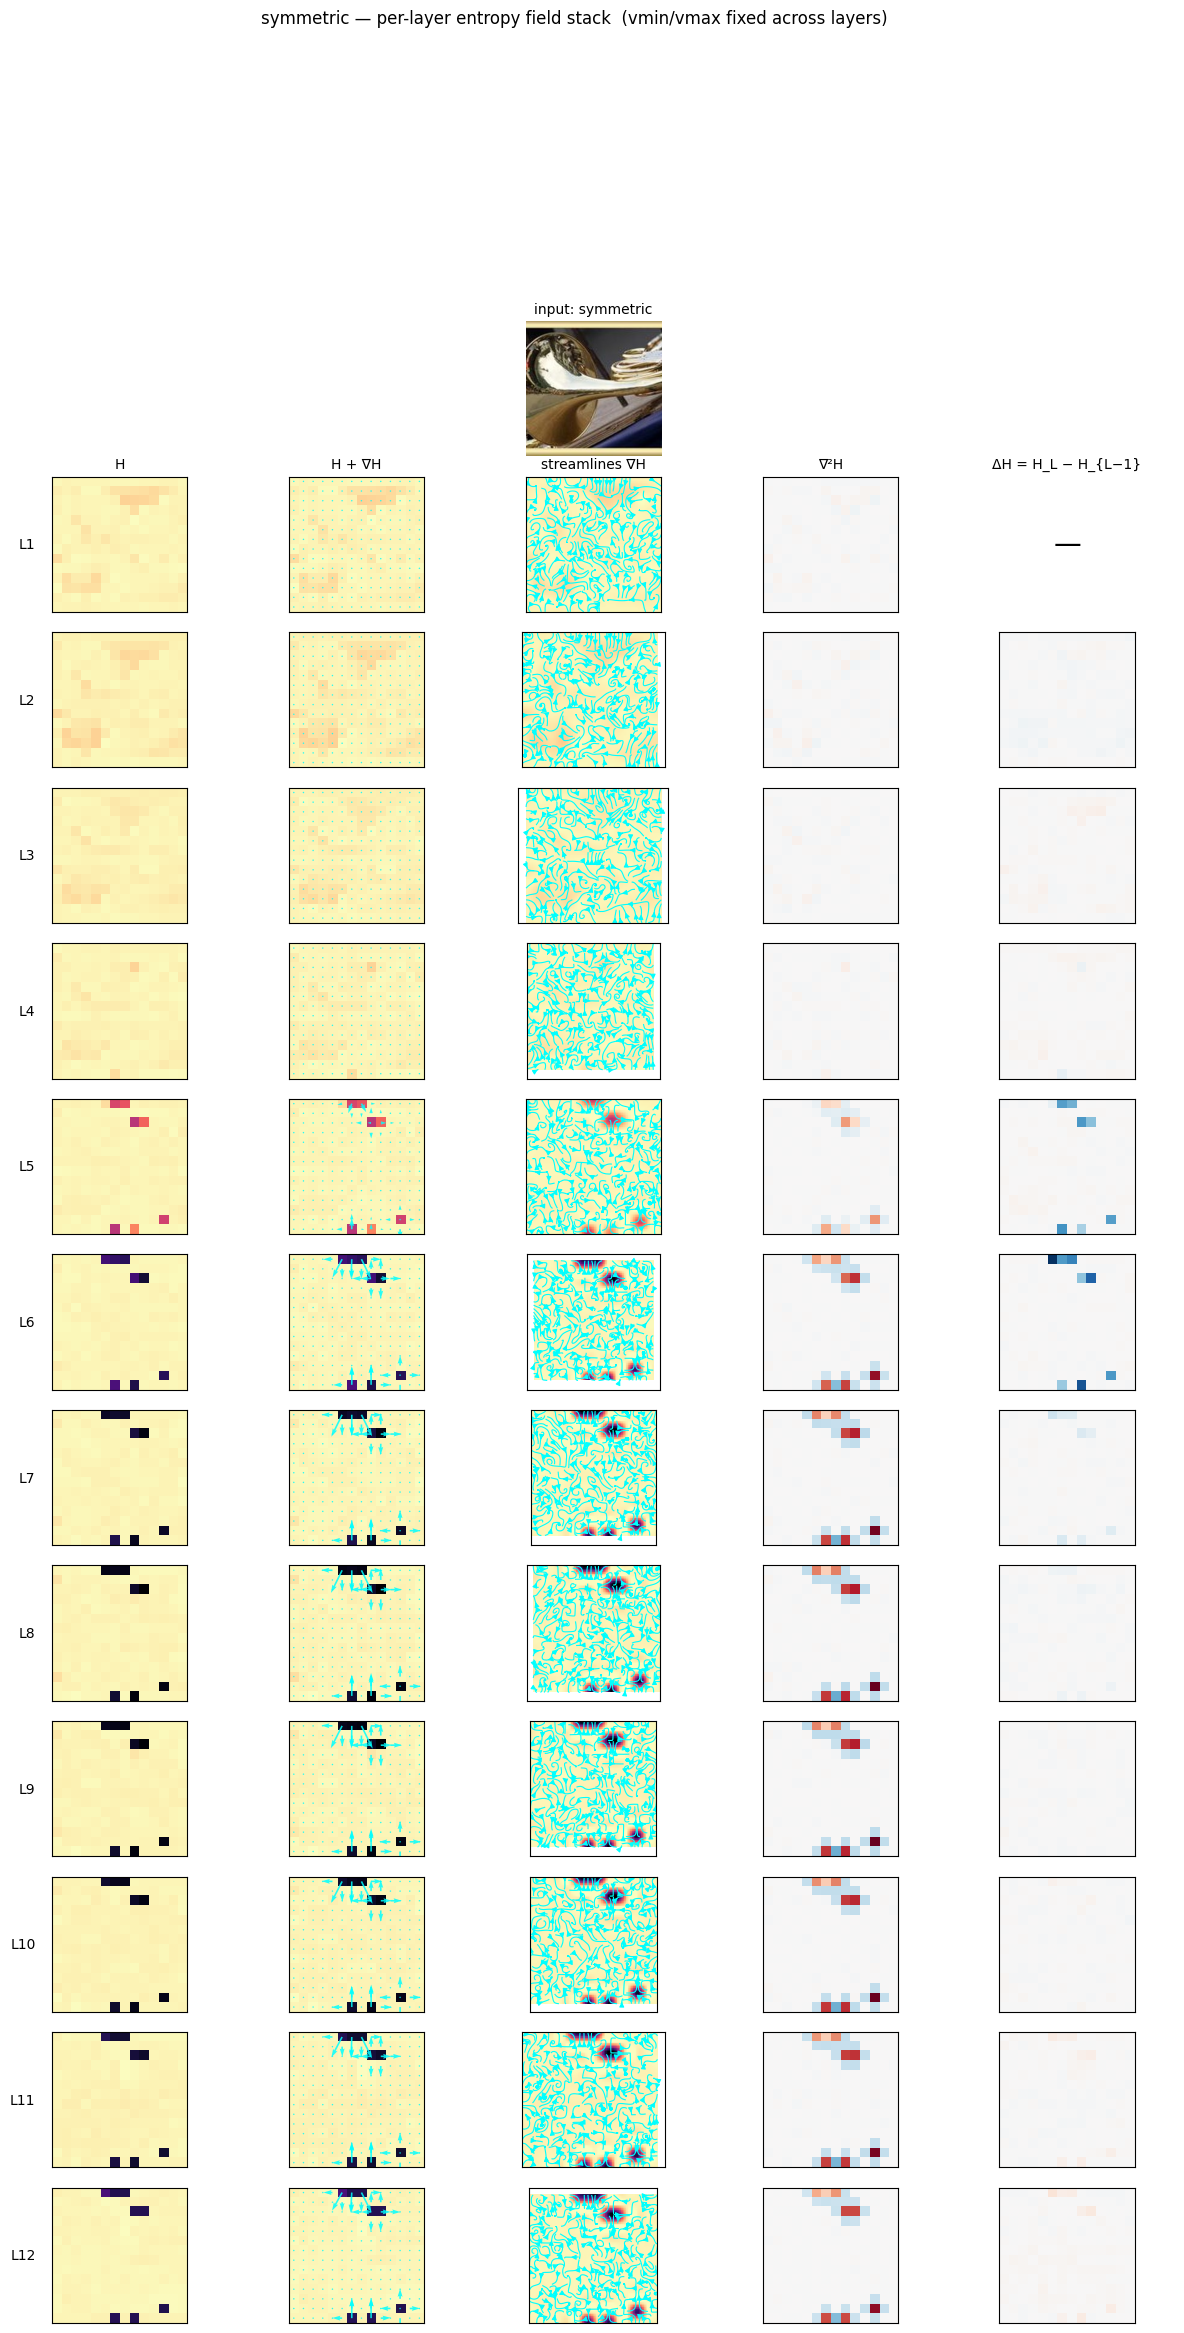

In [6]:
def upsample(arr2d: np.ndarray, factor: int = 4) -> np.ndarray:
    return scipy.ndimage.zoom(arr2d, factor, order=3)


vmin_H, vmax_H = float(H_stack.min()), float(H_stack.max())
vlap = float(np.abs(lap_stack).max()) or 1e-6
vdH = float(np.abs(dH_stack).max()) or 1e-6

fig = plt.figure(figsize=(15, 2.0 * N_BLOCKS + 2.0))
# Reserve top strip for the original image.
gs = fig.add_gridspec(N_BLOCKS + 1, 5, height_ratios=[1.0] + [1.0] * N_BLOCKS,
                      hspace=0.15, wspace=0.10)
ax_img = fig.add_subplot(gs[0, 2])
ax_img.imshow(img_pil)
ax_img.set_title(f"input: {IMG_NAME}", fontsize=10)
ax_img.axis("off")
for c in (0, 1, 3, 4):
    fig.add_subplot(gs[0, c]).axis("off")

UP = 4
xs = np.linspace(0, GRID - 1, GRID * UP)
ys = np.linspace(0, GRID - 1, GRID * UP)

for L in range(N_BLOCKS):
    H = H_stack[L]
    gy, gx, lap = grad_stack[L, 0], grad_stack[L, 1], lap_stack[L]

    # (a) H heatmap
    ax = fig.add_subplot(gs[L + 1, 0])
    ax.imshow(H, vmin=vmin_H, vmax=vmax_H, cmap="magma", origin="upper")
    ax.set_ylabel(f"L{L+1}", fontsize=10, rotation=0, ha="right", va="center", labelpad=12)
    ax.set_xticks([]); ax.set_yticks([])
    if L == 0: ax.set_title("H", fontsize=10)

    # (b) H + ∇H quiver
    ax = fig.add_subplot(gs[L + 1, 1])
    ax.imshow(H, vmin=vmin_H, vmax=vmax_H, cmap="magma", origin="upper")
    yy, xx = np.mgrid[:GRID, :GRID]
    ax.quiver(xx, yy, gx, -gy, color="cyan", scale_units="xy", scale=0.8,
              width=0.012, alpha=0.85)
    ax.set_xticks([]); ax.set_yticks([])
    if L == 0: ax.set_title("H + ∇H", fontsize=10)

    # (c) streamlines on upsampled field
    ax = fig.add_subplot(gs[L + 1, 2])
    H_up = upsample(H, UP)
    gy_up, gx_up = np.gradient(H_up)
    ax.imshow(H_up, vmin=vmin_H, vmax=vmax_H, cmap="magma",
              extent=[0, GRID - 1, GRID - 1, 0])
    try:
        ax.streamplot(xs, ys, gx_up, -gy_up, color="cyan", density=1.2,
                      linewidth=0.8, arrowsize=0.7)
    except Exception:
        pass
    ax.set_xticks([]); ax.set_yticks([])
    if L == 0: ax.set_title("streamlines ∇H", fontsize=10)

    # (d) Laplacian
    ax = fig.add_subplot(gs[L + 1, 3])
    ax.imshow(lap, vmin=-vlap, vmax=vlap, cmap="RdBu_r", origin="upper")
    ax.set_xticks([]); ax.set_yticks([])
    if L == 0: ax.set_title("∇²H", fontsize=10)

    # (e) ΔH (blank for L=0)
    ax = fig.add_subplot(gs[L + 1, 4])
    if L == 0:
        ax.text(0.5, 0.5, "—", ha="center", va="center", fontsize=20,
                transform=ax.transAxes)
        ax.axis("off")
    else:
        ax.imshow(dH_stack[L], vmin=-vdH, vmax=vdH, cmap="RdBu_r", origin="upper")
        ax.set_xticks([]); ax.set_yticks([])
    if L == 0: ax.set_title("ΔH = H_L − H_{L−1}", fontsize=10)

fig.suptitle(f"{IMG_NAME} — per-layer entropy field stack  (vmin/vmax fixed across layers)",
             y=1.0)
fig.savefig(RESULTS_DIR / "field_stack.png", dpi=200, bbox_inches="tight")
print(f"saved {RESULTS_DIR / 'field_stack.png'}")

## 4. Animation: H + streamlines vs depth

In [7]:
fig_a, ax_a = plt.subplots(figsize=(5, 5))
H0_up = upsample(H_stack[0], UP)
im = ax_a.imshow(H0_up, vmin=vmin_H, vmax=vmax_H, cmap="magma",
                 extent=[0, GRID - 1, GRID - 1, 0])
title = ax_a.set_title(f"{IMG_NAME}  L=1 / {N_BLOCKS}", fontsize=11)
ax_a.set_xticks([]); ax_a.set_yticks([])

# matplotlib streamplot can't be cleanly cleared inside FuncAnimation; redraw.
def update(L):
    ax_a.clear()
    H_up = upsample(H_stack[L], UP)
    gy_u, gx_u = np.gradient(H_up)
    ax_a.imshow(H_up, vmin=vmin_H, vmax=vmax_H, cmap="magma",
                extent=[0, GRID - 1, GRID - 1, 0])
    try:
        ax_a.streamplot(xs, ys, gx_u, -gy_u, color="cyan", density=1.2,
                        linewidth=0.8, arrowsize=0.7)
    except Exception:
        pass
    ax_a.set_title(f"{IMG_NAME}  L={L+1} / {N_BLOCKS}", fontsize=11)
    ax_a.set_xticks([]); ax_a.set_yticks([])

anim = animation.FuncAnimation(fig_a, update, frames=N_BLOCKS, interval=500, blit=False)
anim.save(RESULTS_DIR / "depth_movie.gif", writer="pillow", dpi=120)
plt.close(fig_a)
print(f"saved {RESULTS_DIR / 'depth_movie.gif'}")

saved /home/varun/research/eris/results/symmetric/depth_movie.gif


In [8]:
print(f"\ndone: {IMG_NAME}")


done: symmetric
